In [1]:
import os
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
%matplotlib inline

### Functions

In [2]:
def root_directory():
    """
    Gets the current working directory
    within which the base directory will be created
    """
    root = os.getcwd()
    return root

def create_base_directory(geometry):
    """
    This is the base directory for a given grain geometry
    where anything else will be saved in
    """
    root = root_directory()
    geometry_dir = os.path.join(root, geometry)
    if not os.path.isdir(geometry_dir):
        os.mkdir(geometry_dir)
    return geometry_dir

def base_directory(geometry):
    """
    This is the base directory for a given grain geometry
    where anything else will be saved in
    """
    root = root_directory()
    geometry_dir = os.path.join(root, geometry)
    #if not os.path.isdir(geometry_dir):
        #os.mkdir(geometry_dir)
    return geometry_dir

def create_multiphase_directories(base, t, tt):
    """
    creates a set of subdirectories for different proportions
    of taenite and tetrataenite for the multi-phase model
    """
    multiphase_dir_name = 'taenite{}_tetrataenite{}'.format(t, tt)
    multi_phase_subdir = os.path.join(base, multiphase_dir_name)
    if not os.path.isdir(multi_phase_subdir):
        os.mkdir(multi_phase_subdir)
    return multi_phase_subdir    

def tetrataenite_easy_axes():
    """
    define tetrataenite's uniaxial anisotropy axes
    """
    easy1 = 'easy_1_0_0'
    easy2 = 'easy_-1_0_0'
    easy3 = 'easy_0_1_0'
    easy4 = 'easy_0_-1_0'
    easy5 = 'easy_0_0_1'
    easy6 = 'easy_0_0_-1'
    return [easy1, easy2, easy3, easy4, easy5, easy6]

def create_easy_axis_subdirectories(multi_phase_subdir, t, tt):
    """
    for each unianitropy axis of tetrataenite, creates a new subdirectory
    """
    easy_subdirs = []
    for easy in tetrataenite_easy_axes():
        if t == 100 and tt == 0:
            easy_subdir = multi_phase_subdir
            easy_subdirs.append(easy_subdir)
        else:
            easy_subdir = os.path.join(multi_phase_subdir, easy)
            if not os.path.isdir(easy_subdir):
                os.mkdir(easy_subdir)
            easy_subdirs.append(easy_subdir)
    return easy_subdirs
    

def create_elong_subdirectory(multi_phase_subdir, elongation):
    """
    creates a set of elongations subdirectories for each multi phase
    proportion and for each unianisotropy axis for tetrataenite
    """
    elong_subdirs = []
    for elongation in elongations:
        if elongation < 10:
            elongation = 'E0{}'.format(elongation)
        else:
            elongation = 'E{}'.format(elongation)
        #for easy_subdir in easy_subdirs:
        elong_subdir = os.path.join(multi_phase_subdir, elongation)
        if not os.path.isdir(elong_subdir):
            os.mkdir(elong_subdir)
        elong_subdirs.append(elong_subdir)
    return elong_subdirs

def create_elong_subdirectories(elong_subdirs):
    """
    creates the set of ordinary subdirectories for each
    elongation, within a given proportion taenite:tetrataenite 
    and a given easy unianisotropy axis of tetrataenite
    """
    energylog_dirs = []
    hysteresis_dirs = []    
    groundstates_dirs = []
    scripts_dirs = []
    plots_dirs = []
    demag_dirs = []
    # subdirs
    sub_dirs = ['cubit',
                'energylog',
                'final_path',
                'demag',
                'groundstates',
                'hysteresis',
                'initial_path',
                'NEB',
                'patran',
                'plots',
                'scripts']
    # for each elongation, creates the subdirs
    for elong_subdir in elong_subdirs:
        for sub_dir in sub_dirs:
            new_sub_dir = os.path.join(elong_subdir,sub_dir)
            if not os.path.isdir(new_sub_dir):
                os.mkdir(new_sub_dir)
            # energgylog
            if sub_dir == 'energylog':
                energylog_dirs.append(new_sub_dir)
            # hysteresis
            elif sub_dir == 'hysteresis':
                hysteresis_dirs.append(new_sub_dir)
            # scripts
            elif sub_dir == 'scripts':
                scripts_dirs.append(new_sub_dir)
            # groundstates
            elif sub_dir == 'groundstates':
                groundstates_dirs.append(new_sub_dir)
            # plots
            elif sub_dir == 'plots':
                plots_dirs.append(new_sub_dir)
            elif sub_dir == 'demag':
                demag_dirs.append(new_sub_dir)
    return [energylog_dirs, 
            hysteresis_dirs, 
            groundstates_dirs,
            scripts_dirs,
            plots_dirs,
            demag_dirs]

def create_energylog_subdirs(energylog_dirs, sizes):
    """
    creates subdirectories within energylog directory
    """
    subdirs, groundstates_subdirs = [], []
    energylog_sub_dirs = ['groundstates','energy_barriers']
    for energylog_dir in energylog_dirs:
        for energylog_sub_dir in energylog_sub_dirs:
            path = os.path.join(energylog_dir, energylog_sub_dir)
            if not os.path.isdir(path):
                os.mkdir(path)
            if energylog_sub_dir == 'groundstates':
                for size in sizes:
                    size_path = os.path.join(path, str(size))
                    if not os.path.isdir(size_path):
                        os.mkdir(size_path)
                    groundstates_subdirs.append(size_path)
            subdirs.append(path)
    
def create_hysteresis_subdirs(hysteresis_dirs, sizes):
    """
    creates subdirectories within hysteresis directory
    """
    groundstates_subdirs, loops_subdirs, size_hyst_subdirs = [], [], []
    hysteresis_sub_dirs = ['groundstates','loops', 'size_loop']
    for hysteresis_dir in hysteresis_dirs:
        for hysteresis_sub_dir in hysteresis_sub_dirs:
            path = os.path.join(hysteresis_dir, hysteresis_sub_dir)
            if not os.path.isdir(path):
                os.mkdir(path)
            if hysteresis_sub_dir == 'groundstates':
                for size in sizes:
                    size_path = os.path.join(path, str(size))
                    if not os.path.isdir(size_path):
                        os.mkdir(size_path)
                    groundstates_subdirs.append(size_path)
            if hysteresis_sub_dir == 'size_loop':
                for sub in ['states','hyst']:
                    sub_path = os.path.join(path, sub)
                    if not os.path.isdir(sub_path):
                        os.mkdir(sub_path)
                    size_hyst_subdirs.append(size_path)
            else:
                loops_subdirs.append(path)         
                
def create_scripts_subdirs(scripts_dirs):
    """
    creates subdirectories within scripts directory
    """
    scripts_sub_dirs = ['groundstates','energy_barrier', 'batch', 'hysteresis', 'size_hysteresis']
    for scripts_dir in scripts_dirs:
        for scripts_sub_dir in scripts_sub_dirs:
            path = os.path.join(scripts_dir, scripts_sub_dir)
            if not os.path.isdir(path):
                os.mkdir(path)
        
def create_groundstates_subdirs(groundstates_dirs, sizes): 
    """
    creates subdirectories within groundstates directory
    """    
    for groundstates_dir in groundstates_dirs:
        for size in sizes:
            path = os.path.join(groundstates_dir, str(size))
            if not os.path.isdir(path):
                os.mkdir(path)     
                
def create_demag_subdirs(demag_dirs, sizes): 
    """
    creates subdirectories within demag directory
    """    
    for demag_dir in demag_dirs:
        for size in sizes:
            path = os.path.join(demag_dir, str(size))
            if not os.path.isdir(path):
                os.mkdir(path)     
    

def create_all_directories(geometry, elongations, sizes, t, tt):
    """
    the function's name is self-explanatory (haha) 
    """
    # inputs
    geometry = geometry
    elongations = elongations
    sizes = sizes
    t = t
    tt = tt
    # execution
    for i in range(len(t)):
        base = create_base_directory(geometry)
        multi_subdir = create_multiphase_directories(base, t[i], tt[i])
        #easy_subdirs = create_easy_axis_subdirectories(multi_subdir, t[i], tt[i])
        elong_subdirs = create_elong_subdirectory(multi_subdir, elongations)
        elong_sub_subdirs = create_elong_subdirectories(elong_subdirs)

        # sub directories
        energylog_dirs = elong_sub_subdirs[0]
        hysteresis_dirs = elong_sub_subdirs[1]
        groundstates_dirs = elong_sub_subdirs[2]
        scripts_dirs = elong_sub_subdirs[3]
        plots_dirs = elong_sub_subdirs[4]
        demag_dirs = elong_sub_subdirs[5]

        # sub sub directories
        create_energylog_subdirs(energylog_dirs, sizes)
        create_hysteresis_subdirs(hysteresis_dirs, sizes)
        create_scripts_subdirs(scripts_dirs)
        create_groundstates_subdirs(groundstates_dirs, sizes)
        create_demag_subdirs(demag_dirs, sizes)
        
def volume_sphere(size):
    """
    calculate the volume of the sphere with 
    radius = size/2, with size the diameter
    """
    V = (4/3)*np.pi*(size/2)**3
    return V

def long_axis_ellipsoid(volume, aspect_ratio):
    """
    Given the volume and aspect ratio of a grain shape
    calculates the long axis a
    """
    a = (((3/4)*volume)/(np.pi*(aspect_ratio**2)))**(1/3)
    return 2*a

def aspect_ratio(elongation):
    """
    Converts the percentage elongation into the 
    actual aspect ratio (short axis / long axis)
    
    - Percentge elongation = 0 % --> aspect ration = 1
    - Percentge elongation = 50% --> aspect ration = 0.5
    """
    ar = (2 * (elongation/100) +1)**(-1)
    return ar

def create_cubit_multiphase_script(long, inter, short, r_nucleus, phi, l_exc, cubit_path, patran_path):
    """
    creates individual cubit script for multiphas model
    """
    with open(cubit_path, 'w') as f:
        f.write('#!python \n')
        f.write('import cubit \n')
        f.write('cubit.init([""]) \n')
        f.write('cubit.cmd(\"set journal off\") \n')
        if r_nucleus == 0 or r_nucleus == long:
            f.write("cubit.cmd(\"create sphere radius 0.01\") \n")
            f.write("cubit.cmd(\"volume 1 scale X {} Y {} Z {}\") \n".format(short/20, 
                                                                             inter/20, 
                                                                             long/20))
            f.write("cubit.cmd(\"block 1 volume 1\") \n")
            f.write("cubit.cmd(\"volume 1 size {}\") \n".format(l_exc/1000))
            f.write("cubit.cmd(\"volume 1 scheme tetmesh\") \n")
            f.write("cubit.cmd(\"mesh volume 1\") \n")
            f.write("cubit.cmd(\"block all element type tetra4\") \n")
            f.write("cubit.cmd(\"export patran \'{}\'\") \n".format(patran_path))
            f.write("cubit.cmd(\"reset\") \n")

        else:
            # Taenite phase
            f.write("cubit.cmd(\"create sphere radius 0.01\") \n")
            f.write("cubit.cmd(\"volume 1 scale X {} Y {} Z {}\") \n".format(short/20, 
                                                                             inter/20, 
                                                                             long/20))
            f.write("cubit.cmd(\"create sphere radius {}\") \n".format(r_nucleus/1000))
            if phi == 0:
                f.write("cubit.cmd(\"volume 2 move z {}\") \n".format(long/2000))
            elif phi == 90:
                f.write("cubit.cmd(\"volume 2 move y {}\") \n".format(inter/2000))
            f.write("cubit.cmd(\"subtract volume 2 from volume 1\") \n")

            # tetrataenite phase
            f.write("cubit.cmd(\"create sphere radius 0.01\") \n")
            f.write("cubit.cmd(\"volume 3 scale X {} Y {} Z {}\") \n".format(short/20,
                                                              inter/20,
                                                              long/20))
            f.write("cubit.cmd(\"create sphere radius {}\") \n".format(r_nucleus/1000))
            if phi == 0:
                f.write("cubit.cmd(\"volume 4 move z {}\") \n".format(long/2000))
            elif phi == 90:
                f.write("cubit.cmd(\"volume 4 move y {}\") \n".format(inter/2000))
            f.write("cubit.cmd(\"intersect volume 3,4\") \n")

            # block Id's (1=taenite, 2=tetrataenite)
            f.write("cubit.cmd(\"block 1 volume 1\") \n")
            f.write("cubit.cmd(\"block 2 volume 4\") \n")
            f.write("cubit.cmd(\"imprint volume 1 4\") \n")
            f.write("cubit.cmd(\"merge volume 1 4\") \n")

            # meshing
            f.write("cubit.cmd(\"volume 1 4 size {}\") \n".format(l_exc/1000))
            f.write("cubit.cmd(\"volume 1 4 scheme Tetmesh\") \n")
            f.write("cubit.cmd(\"mesh volume 1 4\") \n")
            f.write("cubit.cmd(\"block all element type tetra4\") \n")        
            f.write("cubit.cmd(\"export patran \'{}\' overwrite \") \n".format(patran_path))
            f.write("cubit.cmd(\"reset\") \n")

def cubit_file_path(geometry, elongation, size, t_prop, tt_prop, long, inter, short, phi):
    """
    creates the correct filepath of cubit scripts for the
    multi-phase model
    """
    #r_nucleus = (tt_prop/100)*long
    base = base_directory(geometry)
    if elongation < 10:
        elongation = '0{}'.format(elongation)
    filepath = os.path.join(base,
                            'taenite{}_tetrataenite{}'.format(t_prop, tt_prop),
                            'E{}'.format(str(elongation)),
                            'cubit')
    filename = '{}_r{}_phi{}.jou'.format(str(size),
                                         str(tt_prop),
                                         str(phi))
    full_path = os.path.join(filepath, filename)
    return full_path

def patran_file_path(geometry, elongation, size, t_prop, tt_prop, long, inter, short, phi):
    """
    creates the correct filepath of patran files for the
    multi-phase model
    """
    #r_nucleus = (tt_prop/100)*long
    base = base_directory(geometry)
    elongation = int(elongation)
    if elongation < 10:
        elongation = '0{}'.format(elongation)
    filepath = os.path.join(base,
                            'taenite{}_tetrataenite{}'.format(t_prop, tt_prop),
                            'E{}'.format(str(elongation)),
                            'patran')
    filename = '{}_r{}_phi{}.pat'.format(str(size),
                                         str(tt_prop),
                                         str(phi))
    full_path = os.path.join(filepath, filename)
    full_path = "/" + "/".join(full_path.split('\\')[1:])
    return full_path

def groundstate_file_path(geometry, elongation, size, t_prop, tt_prop, long, inter, short, phi, easy):
    """
    creates the correct filepath of patran files for the
    multi-phase model
    """
    #r_nucleus = (tt_prop/100)*long
    base = base_directory(geometry)
    if elongation < 10:
        elongation = '0{}'.format(elongation)
    filepath = os.path.join(base,
                            'taenite{}_tetrataenite{}'.format(t_prop, tt_prop),
                            'E{}'.format(str(elongation)),
                            'scripts',
                            'groundstates')
    filename = '{}_r{}_phi{}_easy{}'.format(str(size),
                                            str(tt_prop),
                                            str(phi),
                                            str(easy))
    full_path = os.path.join(filepath, filename)
    full_path = "/" + "/".join(full_path.split('\\')[1:])
    return full_path
    
def create_cubit_scripts(geometry, elongations, sizes, t_prop, tt_prop):
    """
    creates individual cubit scripts
    """
    for n in range(len(tt_prop)):
        for elongation in elongations:
            for size in sizes:
                ar = aspect_ratio(elongation)
                vol_sphere = volume_sphere(size)
                long = long_axis_ellipsoid(vol_sphere, ar)
                inter = long * ar
                short = inter
                tt_perc = (tt_prop[n]/100)*long
                cubit_script_path = cubit_file_path(geometry, elongation,
                                                    size, t_prop[n], tt_prop[n],
                                                    long, inter, short, phi)
                patran_path = patran_file_path(geometry, elongation, 
                                               size, t_prop[n], tt_prop[n],
                                               long, inter, short, phi)  
                create_cubit_multiphase_script(long, inter, short,
                                               tt_perc, phi, l_exc,
                                               cubit_script_path,
                                               patran_path) 

def create_cubit_python_script(geometry, elongations, t_prop, tt_prop):
    """
    creates a single python script containing all individual cubit script
    to run all in a row using cubit_python
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            if elongation < 10:
                elongation = '0{}'.format(elongation)
            else:
                elongation = '{}'.format(elongation)
            cubit_scripts_dir = os.path.join(base,
                                            'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                            'E{}'.format(elongation),
                                            'cubit')
            python_script_path = os.path.join(cubit_scripts_dir,
                                              "E{}_cubit_scripts.py".format(elongation))
            with open(python_script_path, 'w') as f:
                f.write('#!python \n')
                f.write('import cubit \n')
                f.write('cubit.init([""]) \n')
                f.write('cubit.cmd(\"set journal off\") \n')
                for cubit_script in os.listdir(cubit_scripts_dir):
                    cubit_script_path = os.path.join(cubit_scripts_dir, cubit_script)
                    with open(cubit_script_path, 'r') as cubitf:
                        content = cubitf.readlines()
                    for line in content[4:]:
                        f.write('{}'.format(line))
                    f.write("\n")      
                    
def taenite_params(*args):
    """
    returns taenite magnetic parameters for a 
    given temperature (20 C or 320 C)
    """
    if args:
        Ms = (1273e3)/2
        K1 = 0
        Aex = (1.13e-11)/4
    else:
        Ms = 1273e3
        K1 = 1e3
        Aex = 1.13e-11            
    return Ms, K1, Aex

def tetrataenite_params():
    """
    returns tetrataenite magnetic parameters at room-T
    """
    Ms = 1390e3
    Ku = 1370e3
    Aex = 1.13e-11
    return Ms, Ku, Aex

def execute_cubit_python_scripts(geometry, elongations, t_prop, tt_prop):
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            if elongation < 10:
                elongation = '0{}'.format(elongation)
            else:
                elongation = '{}'.format(elongation)
            cubit_scripts_dir = os.path.join(base,
                                           'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                           'E{}'.format(elongation),
                                           'cubit')
            python_script_path = os.path.join(cubit_scripts_dir,
                                              "E{}_cubit_scripts.py".format(elongation))
            # execute
            os.system("cubit_python {} ".format(python_script_path))
            
            
def create_groundstates_scripts(geometry, elongations, sizes, t_prop, tt_prop, n_lem):
    """
    creates groundstates scripts for the multi phase model
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            for size in sizes:
                ar = aspect_ratio(elongation)
                vol_sphere = volume_sphere(size)
                long = long_axis_ellipsoid(vol_sphere, ar)
                inter = long * ar
                short = inter
                patran_path = patran_file_path(geometry, elongation, size, 
                                               t_prop[n], tt_prop[n], long, 
                                               inter, short, phi)
                for easy in range(1,4):
                    if tt_prop[n]==0:
                        easy = 1
                    groundstates_script_path = groundstate_file_path(geometry, elongation,
                                                                     size, t_prop[n],
                                                                     tt_prop[n], long,
                                                                     inter, short, phi, easy) 
                    with open(groundstates_script_path, 'w') as f:                    
                        for state in range(1, n_lem+1):
                            if tt_prop[n] == 0:
                                f.write("! Only taenite, random state {} \n".format(state))
                            else:
                                f.write("! Tetrataenite EasyAxis {}, random state {} \n".format(easy, state))
                            f.write(" \n")
                            f.write("Set MaxMeshNumber 1 \n")
                            f.write("Set MaxEnergyEvaluations 10000 \n")
                            f.write("ReadMesh 1 {} \n".format(patran_path))
                            # if there is only taenite
                            Ms, K1, Aex = taenite_params()
                            if tt_prop[n] == 0:                              
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(K1))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Cubic anisotropy \n")
                                f.write(" \n")
                            # if there is only tetrataenite
                            elif tt_prop[n] == 100:
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(Ku))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Uniaxial anisotropy \n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 \n")
                                f.write("\n")    
                            else:
                                # taenite
                                Ms, K1, Aex = taenite_params()
                                f.write("SetSubDomain 1 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 1 K1 {} \n".format(K1))
                                f.write("SetSubDomain 1 Aex {} \n".format(Aex))
                                f.write("Cubic Anisotropy SD = 1\n")
                                f.write(" \n")
                                
                                # tetrataenite
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("SetSubDomain 2 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 2 K1 {} \n".format(Ku))
                                f.write("SetSubDomain 2 Aex {} \n".format(Aex))
                                f.write("Uniaxial Anisotropy SD = 2\n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 SD = 2 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 SD = 2 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 SD = 2 \n")
                                f.write("\n")    
                            
                            # initial random state
                            if tt_prop[n] == 0:                              
                                f.write("Randomize All Moments \n".format(Ms))
                            else:    
                                f.write("Randomize All Moments SD = 1 \n")
                                f.write("Randomize All Moments SD = 2 \n")
                            f.write(" \n")
                            energylog_path = os.path.join(base,
                                                          'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                            tt_prop[n]),
                                                          'E{}'.format(elongation),
                                                          'energylog',
                                                          'groundstates',
                                                          str(size),
                                                          '{}_r{}_phi{}_easy{}_{}'.format(str(size),
                                                                                          str(tt_prop[n]),
                                                                                          str(phi),
                                                                                          str(easy),
                                                                                          str(state)))
                            energylog_path = "/" + "/".join(energylog_path.split('\\')[1:])
                            f.write("Energylog {}\n".format(energylog_path))
                            f.write("Minimize \n")
                            f.write(" \n")
                            groundstate_path = os.path.join(base,
                                                          'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                            tt_prop[n]),
                                                            'E{}'.format(elongation),
                                                            'groundstates',
                                                            str(size),
                                                            '{}_r{}_phi{}_easy{}_{}'.format(str(size),
                                                                                            str(tt_prop[n]),
                                                                                            str(phi),
                                                                                            str(easy),
                                                                                            str(state)))
                            groundstate_path = "/" + "/".join(groundstate_path.split('\\')[1:])
                            f.write("WriteMagnetization {} [Block] \n".format(groundstate_path))
                            demag_path = os.path.join(base,
                                                      'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                        tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'demag',
                                                    str(size),
                                                    '{}_r{}_phi{}_easy{}_{}'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            demag_path = "/" + "/".join(demag_path.split('\\')[1:])
                            f.write("WriteDemag {} [Block] \n".format(demag_path))
                            hyst_path = os.path.join(base,
                                                     'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                       tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'hysteresis',
                                                    'groundstates',
                                                    str(size),
                                                    '{}_r{}_phi{}_easy{}_{}'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            hyst_path = "/" + "/".join(hyst_path.split('\\')[1:])
                            f.write("WriteHyst {} \n".format(hyst_path))
                            f.write("CloseLogFile \n")                            
                            f.write(" \n")


In [3]:
def create_size_hysteresis_scripts_up(geometry, elongations, sizes, t_prop, tt_prop, n_lem):
    """
    creates size hysteresis scripts for the multi phase model
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            for size in sizes:
                elongation = int(elongation)
                ar = aspect_ratio(elongation)
                vol_sphere = volume_sphere(size)
                long = long_axis_ellipsoid(vol_sphere, ar)
                inter = long * ar
                short = inter
                patran_path = patran_file_path(geometry, elongation, size, 
                                               t_prop[n], tt_prop[n], long, 
                                               inter, short, phi)
                for easy in range(1,4):
                    if tt_prop[n] == 0:
                        easy = 1
                    elongation = int(elongation)
                    if elongation < 10:
                        elongation = '0{}'.format(elongation)
                    groundstates_script_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'scripts',
                                                    'size_hysteresis',
                                                    '{}_r{}_phi{}_easy{}_up'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy)))
                    groundstates_script_path = "/" + "/".join(groundstates_script_path.split('\\')[1:])
                    with open(groundstates_script_path, 'w') as f:                    
                        for state in range(1, n_lem+1):
                            if tt_prop[n] == 0:
                                f.write("! Only taenite, random state {} \n".format(state))
                            else:
                                f.write("! Tetrataenite EasyAxis {}, random state {} \n".format(easy, state))
                            f.write(" \n")
                            f.write("Set MaxMeshNumber 1 \n")
                            f.write("Set MaxEnergyEvaluations 10000 \n")
                            f.write("ReadMesh 1 {} \n".format(patran_path))
                            # if there is only taenite
                            Ms, K1, Aex = taenite_params()
                            if tt_prop[n] == 0:                              
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(K1))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Cubic anisotropy \n")
                                f.write(" \n")
                            # if there is only tetrataenite
                            elif tt_prop[n] == 100:
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(Ku))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Uniaxial anisotropy \n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 \n")
                                f.write("\n")    
                            else:
                                # taenite
                                Ms, K1, Aex = taenite_params()
                                f.write("SetSubDomain 1 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 1 K1 {} \n".format(K1))
                                f.write("SetSubDomain 1 Aex {} \n".format(Aex))
                                f.write("Cubic Anisotropy SD = 1 \n")
                                f.write(" \n")
                                
                                # tetrataenite
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("SetSubDomain 2 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 2 K1 {} \n".format(Ku))
                                f.write("SetSubDomain 2 Aex {} \n".format(Aex))
                                f.write("Uniaxial Anisotropy SD = 2\n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 SD = 2 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 SD = 2 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 SD = 2 \n")
                                f.write("\n")    
                            
                            # initial random state
                            if tt_prop[n] == 0:                              
                                f.write("Uniform Magnetization 0 0 1.0001 \n")
                                f.write("Randomize Magnetization 10 \n")
                            else:
                                f.write("Uniform Magnetization 0 0 1.0001 SD = 1\n")
                                f.write("Randomize Magnetization 10 SD = 1 \n")
                                if easy == 1:
                                    f.write("Uniform Magnetization 1.0001 0 0 SD = 2 \n")
                                elif easy == 2:
                                    f.write("Uniform Magnetization 0 1.0001 0 SD = 2 \n")
                                elif easy == 3:
                                    f.write("Uniform Magnetization 0 0 1.0001  SD = 2 \n")
                                f.write("\n")    
                                f.write("Randomize Magnetization 10  SD = 2 \n")
                            f.write(" \n")
                            f.write("Minimize \n")
                            f.write(" \n")
                            sols_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'hysteresis',
                                                    'size_loop',
                                                    'states',
                                                    '{}_r{}_phi{}_easy{}_{}_up'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            sols_path = "/" + "/".join(sols_path.split('\\')[1:])
                            f.write("WriteMagnetization {} [Block] \n".format(sols_path))
                            hyst_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'hysteresis',
                                                    'size_loop',
                                                    'hyst',
                                                    '{}_r{}_phi{}_easy{}_{}_up'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            hyst_path = "/" + "/".join(hyst_path.split('\\')[1:])
                            f.write("WriteHyst {} \n".format(hyst_path))
                            f.write("CloseLogFile \n")                            
                            f.write(" \n")


In [4]:
def create_size_hysteresis_scripts_down(geometry, elongations, sizes, t_prop, tt_prop, n_lem):
    """
    creates size hysteresis scripts for the multi phase model
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            for size in sizes:
                elongation = int(elongation)
                ar = aspect_ratio(elongation)
                vol_sphere = volume_sphere(size)
                long = long_axis_ellipsoid(vol_sphere, ar)
                inter = long * ar
                short = inter
                patran_path = patran_file_path(geometry, elongation, size, 
                                               t_prop[n], tt_prop[n], long, 
                                               inter, short, phi)
                for easy in range(1,4):
                    if tt_prop[n] == 0:
                        easy = 1
                    elongation = int(elongation)
                    if elongation < 10:
                        elongation = '0{}'.format(elongation)
                    groundstates_script_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'scripts',
                                                    'size_hysteresis',
                                                    '{}_r{}_phi{}_easy{}_down'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy)))
                    groundstates_script_path = "/" + "/".join(groundstates_script_path.split('\\')[1:])
                    with open(groundstates_script_path, 'w') as f:                    
                        for state in range(1, n_lem+1):
                            if tt_prop[n] == 0:
                                f.write("! Only taenite, random state {} \n".format(state))
                            else:
                                f.write("! Tetrataenite EasyAxis {}, random state {} \n".format(easy, state))
                            f.write(" \n")
                            f.write("Set MaxMeshNumber 1 \n")
                            f.write("Set MaxEnergyEvaluations 10000 \n")
                            f.write("ReadMesh 1 {} \n".format(patran_path))
                            # if there is only taenite
                            Ms, K1, Aex = taenite_params()
                            if tt_prop[n] == 0:                              
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(K1))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Cubic anisotropy \n")
                                f.write(" \n")
                            # if there is only tetrataenite
                            elif tt_prop[n] == 100:
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(Ku))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Uniaxial anisotropy \n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 \n")
                                f.write("\n")    
                            else:
                                # taenite
                                Ms, K1, Aex = taenite_params()
                                f.write("SetSubDomain 1 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 1 K1 {} \n".format(K1))
                                f.write("SetSubDomain 1 Aex {} \n".format(Aex))
                                f.write("Cubic Anisotropy SD = 1 \n")
                                f.write(" \n")
                                
                                # tetrataenite
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("SetSubDomain 2 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 2 K1 {} \n".format(Ku))
                                f.write("SetSubDomain 2 Aex {} \n".format(Aex))
                                f.write("Uniaxial Anisotropy SD = 2 \n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 SD = 2 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 SD = 2 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 SD = 2 \n")
                                f.write("\n")    
                            
                            # initial random state
                            if tt_prop[n] == 0:                              
                                f.write("Vortex 0 0 1.0001 0.002 LH \n")
                                f.write("Randomize Magnetization 10 \n")
                            else:
                                f.write("Vortex 0 1.0001 0 0.02 LH SD = 1 \n")
                                f.write("Randomize Magnetization 10 SD = 1 \n")
                                if easy == 1:
                                    f.write("Vortex 1.0001 0 0 0.02 LH SD = 2 \n")
                                elif easy == 2:
                                    f.write("Vortex 0 1.0001 0 0.02 LH 0 SD = 2 \n")
                                elif easy == 3:
                                    f.write("Vortex 0 0 1.0001 0.02 LH  SD = 2 \n")
                                f.write("\n")    
                                f.write("Randomize Magnetization 10  SD = 2 \n")
                            f.write(" \n")
                            f.write("Minimize \n")
                            f.write(" \n")
                            sols_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'hysteresis',
                                                    'size_loop',
                                                    'states',
                                                    '{}_r{}_phi{}_easy{}_{}_down'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            sols_path = "/" + "/".join(sols_path.split('\\')[1:])
                            f.write("WriteMagnetization {} [Block] \n".format(sols_path))
                            hyst_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'hysteresis',
                                                    'size_loop',
                                                    'hyst',
                                                    '{}_r{}_phi{}_easy{}_{}_down'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            hyst_path = "/" + "/".join(hyst_path.split('\\')[1:])
                            f.write("WriteHyst {} \n".format(hyst_path))
                            f.write("CloseLogFile \n")                            
                            f.write(" \n")


In [5]:
def create_size_hysteresis_scripts_down_SSV_x(geometry, elongations, sizes, t_prop, tt_prop, n_lem):
    """
    creates size hysteresis scripts for the multi phase model
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            for size in sizes:
                elongation = int(elongation)
                ar = aspect_ratio(elongation)
                vol_sphere = volume_sphere(size)
                long = long_axis_ellipsoid(vol_sphere, ar)
                inter = long * ar
                short = inter
                patran_path = patran_file_path(geometry, elongation, size, 
                                               t_prop[n], tt_prop[n], long, 
                                               inter, short, phi)
                for easy in range(1,4):
                    if tt_prop[n] == 0:
                        easy = 1
                    elongation = int(elongation)
                    if elongation < 10:
                        elongation = '0{}'.format(elongation)
                    groundstates_script_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'scripts',
                                                    'size_hysteresis',
                                                    '{}_r{}_phi{}_easy{}_down_SSV_x'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy)))
                    groundstates_script_path = "/" + "/".join(groundstates_script_path.split('\\')[1:])
                    with open(groundstates_script_path, 'w') as f:                    
                        for state in range(1, n_lem+1):
                            if tt_prop[n] == 0:
                                f.write("! Only taenite, random state {} \n".format(state))
                            else:
                                f.write("! Tetrataenite EasyAxis {}, random state {} \n".format(easy, state))
                            f.write(" \n")
                            f.write("Set MaxMeshNumber 1 \n")
                            f.write("Set MaxEnergyEvaluations 10000 \n")
                            f.write("ReadMesh 1 {} \n".format(patran_path))
                            # if there is only taenite
                            Ms, K1, Aex = taenite_params()
                            if tt_prop[n] == 0:                              
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(K1))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Cubic anisotropy \n")
                                f.write(" \n")
                            # if there is only tetrataenite
                            elif tt_prop[n] == 100:
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("Set Ms {} \n".format(Ms))
                                f.write("Set K1 {} \n".format(Ku))
                                f.write("Set Aex {} \n".format(Aex))
                                f.write("Uniaxial anisotropy \n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 \n")
                                f.write("\n")    
                            else:
                                # taenite
                                Ms, K1, Aex = taenite_params()
                                f.write("SetSubDomain 1 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 1 K1 {} \n".format(K1))
                                f.write("SetSubDomain 1 Aex {} \n".format(Aex))
                                f.write("Cubic Anisotropy SD = 1 \n")
                                f.write(" \n")
                                
                                # tetrataenite
                                Ms, Ku, Aex = tetrataenite_params()
                                f.write("SetSubDomain 2 Ms {} \n".format(Ms))
                                f.write("SetSubDomain 2 K1 {} \n".format(Ku))
                                f.write("SetSubDomain 2 Aex {} \n".format(Aex))
                                f.write("Uniaxial Anisotropy SD = 2 \n")
                                f.write(" \n")
                                if easy == 1:
                                    f.write("EasyAxis 1 0 0 SD = 2 \n")
                                elif easy == 2:
                                    f.write("EasyAxis 0 1 0 SD = 2 \n")
                                elif easy == 3:
                                    f.write("EasyAxis 0 0 1 SD = 2 \n")
                                f.write("\n")    
                            
                            # initial random state
                            if tt_prop[n] == 0:                              
                                f.write("Vortex 1.0001 0 0 0.02 LH \n")
                                f.write("Randomize Magnetization 10 \n")
                            else:
                                f.write("Vortex 0 1.0001 0 0.02 LH SD = 1 \n")
                                f.write("Randomize Magnetization 10 SD = 1 \n")
                                if easy == 1:
                                    f.write("Vortex 1.0001 0 0 0.02 LH SD = 2 \n")
                                elif easy == 2:
                                    f.write("Vortex 0 1.0001 0 0.02 LH 0 SD = 2 \n")
                                elif easy == 3:
                                    f.write("Vortex 0 0 1.0001 0.02 LH  SD = 2 \n")
                                f.write("\n")    
                                f.write("Randomize Magnetization 10  SD = 2 \n")
                            f.write(" \n")
                            f.write("Minimize \n")
                            f.write(" \n")
                            sols_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'hysteresis',
                                                    'size_loop',
                                                    'states',
                                                    '{}_r{}_phi{}_easy{}_{}_down_SSV_x'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            sols_path = "/" + "/".join(sols_path.split('\\')[1:])
                            f.write("WriteMagnetization {} [Block] \n".format(sols_path))
                            hyst_path = os.path.join(base,
                                                    'taenite{}_tetrataenite{}'.format(t_prop[n],
                                                                                      tt_prop[n]),
                                                    'E{}'.format(elongation),
                                                    'hysteresis',
                                                    'size_loop',
                                                    'hyst',
                                                    '{}_r{}_phi{}_easy{}_{}_down_SSV_x'.format(str(size),
                                                                                    str(tt_prop[n]),
                                                                                    str(phi),
                                                                                    str(easy),
                                                                                    str(state)))
                            hyst_path = "/" + "/".join(hyst_path.split('\\')[1:])
                            f.write("WriteHyst {} \n".format(hyst_path))
                            f.write("CloseLogFile \n")                            
                            f.write(" \n")


In [6]:
def create_batch_script_size_hysteresis_up(geometry, elongations, t_prop, tt_prop):
    """
    creates a single batch script containing all individual 
    size hysteresis mscripts to run all in a row using
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            if elongation < 10:
                elongation = '0{}'.format(elongation)
            else:
                elongation = '{}'.format(elongation)
            mscripts_dir = os.path.join(base,
                                        'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                        'E{}'.format(elongation),
                                        'scripts',
                                        'size_hysteresis')
            batch_script_path = os.path.join(base,
                                            'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                            'E{}'.format(elongation),
                                            'scripts',
                                            'batch',
                                            'E{}_size_hysteresis_up'.format(elongation) + '.bat')
            with open(batch_script_path, 'w') as f:
                for file in os.listdir(mscripts_dir):
                    if 'up' in file:
                        filepath = os.path.join(mscripts_dir, file)
                        f.write('merrill {} \n'.format(filepath))

def create_batch_script_size_hysteresis_down(geometry, elongations, t_prop, tt_prop):
    """
    creates a single batch script containing all individual 
    size hysteresis mscripts to run all in a row using
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            if elongation < 10:
                elongation = '0{}'.format(elongation)
            else:
                elongation = '{}'.format(elongation)
            mscripts_dir = os.path.join(base,
                                        'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                        'E{}'.format(elongation),
                                        'scripts',
                                        'size_hysteresis')
            batch_script_path = os.path.join(base,
                                            'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                            'E{}'.format(elongation),
                                            'scripts',
                                            'batch',
                                            'E{}_size_hysteresis_down'.format(elongation) + '.bat')
            with open(batch_script_path, 'w') as f:
                for file in os.listdir(mscripts_dir):
                    if 'down' in file:
                        filepath = os.path.join(mscripts_dir, file)
                        f.write('merrill {} \n'.format(filepath))
                        
def create_batch_script_size_hysteresis_down_SSV(geometry, elongations, t_prop, tt_prop):
    """
    creates a single batch script containing all individual 
    size hysteresis mscripts to run all in a row using
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            if elongation < 10:
                elongation = '0{}'.format(elongation)
            else:
                elongation = '{}'.format(elongation)
            mscripts_dir = os.path.join(base,
                                        'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                        'E{}'.format(elongation),
                                        'scripts',
                                        'size_hysteresis')
            batch_script_path = os.path.join(base,
                                            'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                            'E{}'.format(elongation),
                                            'scripts',
                                            'batch',
                                            'E{}_size_hysteresis_down_SSV'.format(elongation) + '.bat')
            with open(batch_script_path, 'w') as f:
                for file in os.listdir(mscripts_dir):
                    if 'down' and 'SSV' in file:
                        filepath = os.path.join(mscripts_dir, file)
                        f.write('merrill {} \n'.format(filepath))
                        
def create_batch_script_size_hysteresis_down_SSV_x(geometry, elongations, t_prop, tt_prop):
    """
    creates a single batch script containing all individual 
    size hysteresis mscripts to run all in a row using
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            if elongation < 10:
                elongation = '0{}'.format(elongation)
            else:
                elongation = '{}'.format(elongation)
            mscripts_dir = os.path.join(base,
                                        'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                        'E{}'.format(elongation),
                                        'scripts',
                                        'size_hysteresis')
            batch_script_path = os.path.join(base,
                                            'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                            'E{}'.format(elongation),
                                            'scripts',
                                            'batch',
                                            'E{}_size_hysteresis_down_SSV_x'.format(elongation) + '.bat')
            with open(batch_script_path, 'w') as f:
                for file in os.listdir(mscripts_dir):
                    if 'down' and 'SSV' and '_x' in file:
                        filepath = os.path.join(mscripts_dir, file)
                        f.write('merrill {} \n'.format(filepath))

In [7]:
def create_batch_script_groundstates(geometry, elongations, t_prop, tt_prop):
    """
    creates a single batch script containing all individual 
    mscripts script to run all in a row using
    """
    base = base_directory(geometry)
    for n in range(len(tt_prop)):
        for elongation in elongations:
            if elongation < 10:
                elongation = '0{}'.format(elongation)
            else:
                elongation = '{}'.format(elongation)
            mscripts_dir = os.path.join(base,
                                        'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                        'E{}'.format(elongation),
                                        'scripts',
                                        'groundstates')
            batch_script_path = os.path.join(base,
                                            'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                                            'E{}'.format(elongation),
                                            'scripts',
                                            'batch',
                                            'E{}_groundstates'.format(elongation) + '.bat')
            with open(batch_script_path, 'w') as f:
                for file in os.listdir(mscripts_dir):
                    filepath = os.path.join(mscripts_dir, file)
                    f.write('merrill {} \n'.format(filepath))

### Inputs

In [10]:
geometry = 'spheroid'
elongations = [40, 50]
sizes = [38,39,40,41,42,43, 44, 45, 46, 48, 50]
t_prop = np.arange(100,90,-10) # percentage of taenite
tt_prop = 100 - t_prop # percentage of tetrataenite
phi = 0 # angle from which tetrataenite phase starts to nucleate
l_exc = 3 # exchange length (in nm)

### Execution

* Create all directories

In [11]:
create_all_directories(geometry, elongations, sizes, t_prop, tt_prop)

* Create all cubit scripts

In [12]:
create_cubit_scripts(geometry, elongations, sizes, t_prop, tt_prop)

* create individual python scripts to run in cubit_python

In [19]:
create_cubit_python_script(geometry, elongations, t_prop, tt_prop)

* Execute cubit scripts

In [29]:
execute_cubit_python_scripts(geometry, elongations, t_prop, tt_prop)

* Create groundstates scripts

In [9]:
create_groundstates_scripts(geometry, elongations, sizes, t_prop, tt_prop, 100)

* Create batch scripts

In [10]:
create_batch_script_groundstates(geometry, elongations, t_prop, tt_prop)

* Create size hysteresis loops scripts

In [26]:
create_size_hysteresis_scripts_up(geometry, elongations, sizes, t_prop, tt_prop, 1)
create_size_hysteresis_scripts_down(geometry, elongations, sizes, t_prop, tt_prop, 1)
create_size_hysteresis_scripts_down_SSV(geometry, elongations, sizes, t_prop, tt_prop, 1)
create_size_hysteresis_scripts_down_SSV_x(geometry, elongations, sizes, t_prop, tt_prop, 1)

In [27]:
create_batch_script_size_hysteresis_up(geometry, elongations, t_prop, tt_prop)
create_batch_script_size_hysteresis_down(geometry, elongations, t_prop, tt_prop)
create_batch_script_size_hysteresis_down_SSV(geometry, elongations, t_prop, tt_prop)
create_batch_script_size_hysteresis_down_SSV_x(geometry, elongations, t_prop, tt_prop)

* Plot

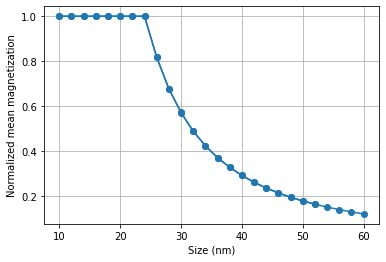

In [69]:
E00 = '/Users/josea/Desktop/Documents/PhD/Taenite/grain_size_hysteresis/spheroid/taenite100_tetrataenite0/E00/hysteresis/size_loop/hyst'
up, down = [], []
for file in os.listdir(E00):
    if 'up' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E00, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
        mx = float(content[-1].split(',')[-3])
        my = float(content[-1].split(',')[-2])
        mz = float(content[-1].split(',')[-1])
        m = np.sqrt(mx**2 + my**2 + mz**2)
        up.append([int(size),m])
    if 'down' and 'SSV' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E00, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
        mx = float(content[-1].split(',')[-3])
        my = float(content[-1].split(',')[-2])
        mz = float(content[-1].split(',')[-1])
        m = np.sqrt(mx**2 + my**2 + mz**2)
        down.append([int(size),m])
            
df_up_0 = pd.DataFrame(up)
df_up_0.columns = ['size', 'mag']

df_down_0 = pd.DataFrame(down)
df_down_0.columns = ['size', 'mag']

plt.plot(df_up_0['size'], df_up_0['mag'], 'o-', color = 'tab:blue')
plt.xlabel('Size (nm)')
plt.ylabel('Normalized mean magnetization')
plt.plot(df_down_0['size'][:-4], df_down_0['mag'][:-4], 'o-')
plt.grid()
plt.show()

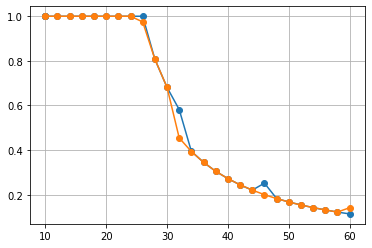

In [76]:
E05 = '/Users/josea/Desktop/Documents/PhD/Taenite/grain_size_hysteresis/spheroid/taenite100_tetrataenite0/E05/hysteresis/size_loop/hyst'
up, down = [], []
for file in os.listdir(E05):
    if 'up' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E05, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
        mx = float(content[-1].split(',')[-3])
        my = float(content[-1].split(',')[-2])
        mz = float(content[-1].split(',')[-1])
        m = np.sqrt(mx**2 + my**2 + mz**2)
        up.append([int(size),m])
    if 'down' and 'SSV' and '_x' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E05, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
        mx = float(content[-1].split(',')[-3])
        my = float(content[-1].split(',')[-2])
        mz = float(content[-1].split(',')[-1])
        m = np.sqrt(mx**2 + my**2 + mz**2)
        down.append([int(size),m])
            
df_up_5 = pd.DataFrame(up)
df_up_5.columns = ['size', 'mag']

df_down_5 = pd.DataFrame(down)
df_down_5.columns = ['size', 'mag']

plt.plot(df_up_5['size'], df_up_5['mag'], 'o-')
plt.plot(df_down_5['size'], df_down_5['mag'], 'o-')
plt.grid()
plt.show()

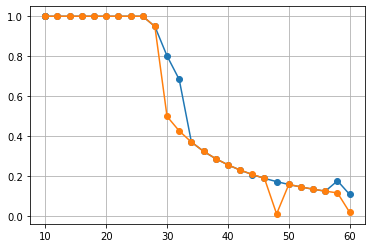

In [92]:
E10 = '/Users/josea/Desktop/Documents/PhD/Taenite/grain_size_hysteresis/spheroid/taenite100_tetrataenite0/E10/hysteresis/size_loop/hyst'
up, down = [], []
for file in os.listdir(E10):
    if 'up' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E10, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            up.append([int(size),m])
    if 'down' and 'SSV' in file and '_x' not in file:
        size = file.split('_')[0]
        filepath = os.path.join(E10, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            down.append([int(size),m])
            
df_up_10 = pd.DataFrame(up)
df_up_10.columns = ['size', 'mag']

df_down_10 = pd.DataFrame(down)
df_down_10.columns = ['size', 'mag']

plt.plot(df_up_10['size'], df_up_10['mag'], 'o-')
plt.plot(df_down_10['size'], df_down_10['mag'], 'o-')
plt.grid()

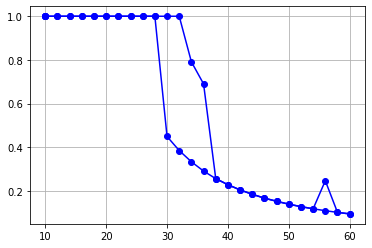

In [123]:
E20 = '/Users/josea/Desktop/Documents/PhD/Taenite/grain_size_hysteresis/spheroid/taenite100_tetrataenite0/E20/hysteresis/size_loop/hyst'
up, down = [], []
for file in os.listdir(E20):
    if 'up' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E20, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            up.append([int(size),m])
    if 'down' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E20, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            down.append([int(size),m])
            
df_up_20 = pd.DataFrame(up)
df_up_20.columns = ['size', 'mag']

df_down_20 = pd.DataFrame(down)
df_down_20.columns = ['size', 'mag']

plt.plot(df_up_20['size'], df_up_20['mag'], 'bo-')
plt.plot(df_down_20['size'], df_down_20['mag'], 'bo-')
plt.grid()

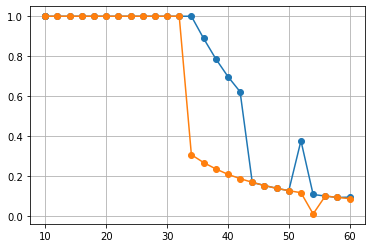

In [124]:
E30 = '/Users/josea/Desktop/Documents/PhD/Taenite/grain_size_hysteresis/spheroid/taenite100_tetrataenite0/E30/hysteresis/size_loop/hyst'
up, down = [], []
for file in os.listdir(E30):
    if 'up' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E30, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-2].split(',')[-3])
            my = float(content[-2].split(',')[-2])
            mz = float(content[-2].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            up.append([int(size),m])
    if 'down' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E30, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            down.append([int(size),m])
            
df_up_30 = pd.DataFrame(up)
df_up_30.columns = ['size', 'mag']

df_down_30 = pd.DataFrame(down)
df_down_30.columns = ['size', 'mag']

plt.plot(df_up_30['size'], df_up_30['mag'], 'o-')
plt.plot(df_down_30['size'], df_down_30['mag'], 'o-')
plt.grid()

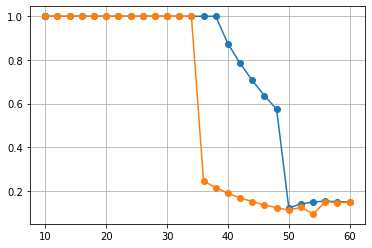

In [138]:
E40 = '/Users/josea/Desktop/Documents/PhD/Taenite/grain_size_hysteresis/spheroid/taenite100_tetrataenite0/E40/hysteresis/size_loop/hyst'
up, down = [], []
for file in os.listdir(E40):
    if 'up' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E40, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            up.append([int(size),m])
    if 'down' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E40, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            down.append([int(size),m])
            
df_up_40 = pd.DataFrame(up)
df_up_40.columns = ['size', 'mag']

df_down_40 = pd.DataFrame(down)
df_down_40.columns = ['size', 'mag']

plt.plot(df_up_40['size'], df_up_40['mag'], 'o-')
plt.plot(df_down_40['size'], df_down_40['mag'], 'o-')
plt.grid()
plt.show()

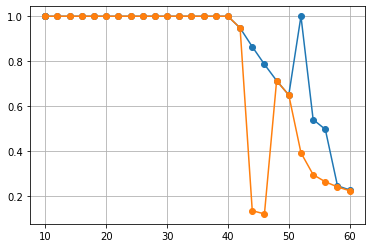

In [143]:
E50 = '/Users/josea/Desktop/Documents/PhD/Taenite/grain_size_hysteresis/spheroid/taenite100_tetrataenite0/E50/hysteresis/size_loop/hyst'
up, down = [], []
for file in os.listdir(E50):
    if 'up' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E50, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            up.append([int(size),m])
    if 'down' in file:
        size = file.split('_')[0]
        filepath = os.path.join(E50, file)
        with open(filepath, 'r') as f:
            content = f.readlines()
            mx = float(content[-1].split(',')[-3])
            my = float(content[-1].split(',')[-2])
            mz = float(content[-1].split(',')[-1])
            m = np.sqrt(mx**2 + my**2 + mz**2)
            down.append([int(size),m])
            
df_up_50 = pd.DataFrame(up)
df_up_50.columns = ['size', 'mag']

df_down_50 = pd.DataFrame(down)
df_down_50.columns = ['size', 'mag']

plt.plot(df_up_50['size'], df_up_50['mag'], 'o-')
plt.plot(df_down_50['size'], df_down_50['mag'], 'o-')
plt.grid()
plt.show()

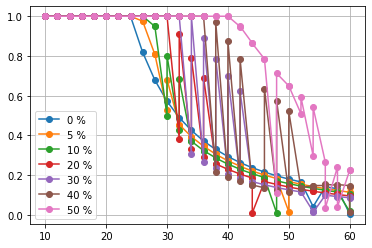

In [21]:
plt.plot(df_down_0['size'], df_down_0['mag'], 'o-', label = '0 %')
plt.plot(df_down_05['size'], df_down_05['mag'], 'o-', label = '5 %')
plt.plot(df_down_10['size'], df_down_10['mag'], 'o-', label = '10 %')
plt.plot(df_down_20['size'], df_down_20['mag'], 'o-', label = '20 %')
plt.plot(df_down_30['size'], df_down_30['mag'], 'o-', label = '30 %')
plt.plot(df_down_40['size'], df_down_40['mag'], 'o-', label = '40 %')
plt.plot(df_down_50['size'], df_down_50['mag'], 'o-', label = '50 %')
plt.legend(loc = 3)
plt.grid()
plt.savefig('/Users/josea/Desktop/grain_size_hyst_taenite.png', dpi = 300)
plt.show()

In [ ]:
plt.plot(df_up['size'], df_up['mag'], 'o-')
plt.plot(df_down_50['size'], df_down_50['mag'], 'o-')

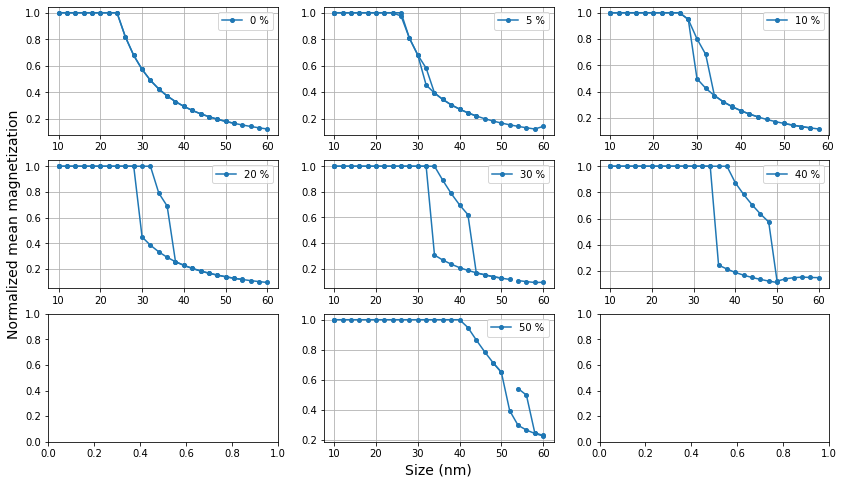

In [154]:
fig = plt.subplots(nrows=3, ncols=3, figsize=(14, 8))

ax1 = plt.subplot(331)
ax1.plot(df_up_0['size'], df_up_0['mag'], 'o-', label = '0 %', color = 'tab:blue', markersize = 4)
ax1.plot(df_down_0['size'][:-4], df_down_0['mag'][:-4], 'o-', color = 'tab:blue', markersize = 4)
ax1.legend()
ax1.grid()

ax2 = plt.subplot(332)
ax2.plot(df_up_5['size'][:-8], df_up_5['mag'][:-8], 'o-', label = '5 %', color = 'tab:blue', markersize = 4)
ax2.plot(df_down_5['size'], df_down_5['mag'], 'o-', color = 'tab:blue', markersize = 4)
ax2.legend()
ax2.grid()

ax3 = plt.subplot(333)
ax3.plot(df_up_10['size'][:-2], df_up_10['mag'][:-2], 'o-', label = '10 %', color = 'tab:blue', markersize = 4)
ax3.plot(df_down_10['size'][:-8], df_down_10['mag'][:-8], 'o-', color = 'tab:blue', markersize = 4)
ax3.plot(df_down_10['size'][-6:-1], df_down_10['mag'][-6:-1], 'o-', color = 'tab:blue', markersize = 4)
ax3.legend()
ax3.grid()

ax4 = plt.subplot(334)
ax4.plot(df_up_20['size'][:-3], df_up_20['mag'][:-3], 'o-', label = '20 %', color = 'tab:blue', markersize = 4)
ax4.plot(df_down_20['size'], df_down_20['mag'], 'o-', color = 'tab:blue', markersize = 4)
ax4.set_ylabel('Normalized mean magnetization', fontsize = 14)
ax4.legend()
ax4.grid()

ax5 = plt.subplot(335)
ax5.plot(df_up_30['size'][:-5], df_up_30['mag'][:-5], 'o-', label = '30 %', color = 'tab:blue', markersize = 4)
ax5.plot(df_up_30['size'][-4:], df_up_30['mag'][-4:], 'o-', color = 'tab:blue', markersize = 4)
ax5.plot(df_down_30['size'][:-4], df_down_30['mag'][:-4], 'o-', color = 'tab:blue', markersize = 4)
ax5.legend()
ax5.grid()

ax6 = plt.subplot(336)
ax6.plot(df_up_40['size'], df_up_40['mag'], 'o-', label = '40 %', color = 'tab:blue', markersize = 4)
ax6.plot(df_down_40['size'][:-5], df_down_40['mag'][:-5], 'o-', color = 'tab:blue', markersize = 4)
ax6.legend()
ax6.grid()

ax8 = plt.subplot(338)
ax8.plot(df_up_50['size'][:-5], df_up_50['mag'][:-5], 'o-', label = '50 %', color = 'tab:blue', markersize = 4)
ax8.plot(df_up_50['size'][-4:], df_up_50['mag'][-4:], 'o-', color = 'tab:blue', markersize = 4)
ax8.plot(df_down_50['size'][-7:], df_down_50['mag'][-7:], 'o-', color = 'tab:blue', markersize = 4)
ax8.set_xlabel('Size (nm)', fontsize = 14)
ax8.legend()
ax8.grid()

plt.savefig('size_hysteresis.png', dpi = 300)
plt.show()

In [152]:
os.getcwd()

'C:\\Users\\josea\\Desktop\\Documents\\PhD\\Taenite\\grain_size_hysteresis'